# Short ncRNA Pipeline Validation (hg38 → mm39)

Tracks short ncRNA genes through every pipeline stage to quantify losses:

1. **Input** → union transcript collapsing (how many short ncRNA union transcripts?)
2. **TOGA** → orthologous region detection (how many got hits? 1 vs >1 chains?)
3. **Short ncRNA pipeline** → final results (MMD scores, biotype breakdown)

In [15]:
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

# --- Paths ---
PIPELINE_DIR = REPO_ROOT / "hg38_vs_mm39_sncRNA_only"
INPUT_BED = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
INPUT_META = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.transcript_metadata.tsv"

UNION_BED = PIPELINE_DIR / "union_transcripts.bed"
UNION_META = PIPELINE_DIR / "union_transcripts_metadata.tsv"
RNA_TOGA = PIPELINE_DIR / "toga_mini_results" / "rna_orthologous_regions.tsv"
TOGA_RAW = PIPELINE_DIR / "toga_mini_results" / "toga_orthologous_regions.tsv"
JOBLIST = PIPELINE_DIR / "joblists" / "short_ncRNA_joblist.txt"
RESULTS_BED = PIPELINE_DIR / "to_analyse.bed"
DETAILS_TSV = PIPELINE_DIR / "intermediate_bed_files" / "short_ncRNA_details.tsv"

ANNOTATION_DIR = REPO_ROOT / "input_data" / "mm39_annotation_validation"
ANNO_BED = ANNOTATION_DIR / "mm39_gencode_all_transcripts.bed"
TRNA_BED = ANNOTATION_DIR / "mm39-tRNAs.bed"

MAX_SHORT_LENGTH = 160

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

## Helper: RNA biotype filter

Same logic as `modules/pipeline/toga_postprocess.py::_is_rna_biotype`.

In [2]:
def is_rna_biotype(biotype: str) -> bool:
    if not biotype:
        return False
    b = biotype.strip().lower().replace("-", "_").replace(" ", "_")
    if b == "protein_coding":
        return False
    if "rna" in b:
        return True
    if b in {"ribozyme"}:
        return True
    return False


def parse_bed12(path):
    """Read BED12 into a DataFrame with transcript length from block sizes."""
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 12:
                continue
            block_sizes = [int(x) for x in parts[10].rstrip(",").split(",") if x]
            rows.append({
                "chrom": parts[0],
                "start": int(parts[1]),
                "end": int(parts[2]),
                "name": parts[3],
                "strand": parts[5],
                "exon_count": int(parts[9]),
                "transcript_length": sum(block_sizes),
            })
    return pd.DataFrame(rows)

## 1. Input: union transcripts that qualify as short ncRNA

A union transcript qualifies for the short pipeline if:
- RNA biotype (contains "rna" or is "ribozyme", excludes protein_coding)
- Length ≤ 160 nt
- Single exon

In [3]:
union_bed = parse_bed12(UNION_BED)
union_meta = pd.read_csv(UNION_META, sep="\t")

union = union_bed.merge(union_meta, left_on="name", right_on="transcript_id", how="left")

print(f"Total union transcripts: {len(union):,}")
print(f"  Biotype breakdown (top 10):")
for bt, n in union["biotype"].value_counts().head(10).items():
    print(f"    {bt}: {n:,}")

Total union transcripts: 79,019
  Biotype breakdown (top 10):
    lncRNA: 34,265
    protein_coding: 19,844
    processed_pseudogene: 9,486
    misc_RNA: 2,207
    unprocessed_pseudogene: 1,953
    snRNA: 1,901
    miRNA: 1,879
    transcribed_unprocessed_pseudogene: 1,596
    transcribed_processed_pseudogene: 1,155
    TEC: 1,029


In [4]:
union["is_rna"] = union["biotype"].apply(is_rna_biotype)
union["is_short"] = (union["transcript_length"] <= MAX_SHORT_LENGTH) & (union["exon_count"] == 1)
union["qualifies"] = union["is_rna"] & union["is_short"]

rna_union = union[union["is_rna"]]
short_candidates = union[union["qualifies"]]

print(f"RNA-biotype union transcripts: {len(rna_union):,}")
print(f"  of which ≤{MAX_SHORT_LENGTH}nt + single-exon: {len(short_candidates):,}")
print()
print(f"Short ncRNA candidate biotypes:")
for bt, n in short_candidates["biotype"].value_counts().items():
    print(f"  {bt}: {n:,}")

RNA-biotype union transcripts: 42,459
  of which ≤160nt + single-exon: 6,733

Short ncRNA candidate biotypes:
  miRNA: 1,876
  snRNA: 1,731
  misc_RNA: 969
  snoRNA: 851
  tRNA: 630
  rRNA_pseudogene: 497
  lncRNA: 64
  rRNA: 47
  scaRNA: 35
  Mt_tRNA: 22
  sRNA: 5
  vault_RNA: 4
  ribozyme: 2


## 2. TOGA: orthologous regions for short ncRNA candidates

How many of the short ncRNA candidates got TOGA hits? How many chains per gene?

In [5]:
toga_rna = pd.read_csv(RNA_TOGA, sep="\t")
print(f"Total RNA TOGA regions: {len(toga_rna):,} (all lengths)")

toga_short = toga_rna[toga_rna["transcript_length"] <= MAX_SHORT_LENGTH].copy()
print(f"TOGA regions for transcripts ≤{MAX_SHORT_LENGTH}nt: {len(toga_short):,}")
print(f"  Unique transcripts with TOGA hit: {toga_short['transcript_id'].nunique():,}")

Total RNA TOGA regions: 42,219 (all lengths)
TOGA regions for transcripts ≤160nt: 2,852
  Unique transcripts with TOGA hit: 2,771


In [6]:
# Chains per transcript
chains_per_gene = toga_short.groupby("transcript_id")["chain_id"].nunique()

n_one_chain = (chains_per_gene == 1).sum()
n_multi_chain = (chains_per_gene > 1).sum()

print(f"Transcripts with exactly 1 chain:  {n_one_chain:,}")
print(f"Transcripts with >1 chains:         {n_multi_chain:,}")
print(f"  max chains for a single gene:     {chains_per_gene.max()}")
print()

# How many short candidates had NO TOGA hit at all?
candidate_ids = set(short_candidates["name"])
toga_hit_ids = set(toga_short["transcript_id"])
no_hit = candidate_ids - toga_hit_ids

print(f"Short candidates in union:    {len(candidate_ids):,}")
print(f"Short candidates with TOGA hit: {len(candidate_ids & toga_hit_ids):,}")
print(f"Short candidates with NO hit:   {len(no_hit):,}  "
      f"({100 * len(no_hit) / len(candidate_ids):.1f}% lost at TOGA stage)")

Transcripts with exactly 1 chain:  2,726
Transcripts with >1 chains:         45
  max chains for a single gene:     18

Short candidates in union:    6,733
Short candidates with TOGA hit: 2,742
Short candidates with NO hit:   3,991  (59.3% lost at TOGA stage)


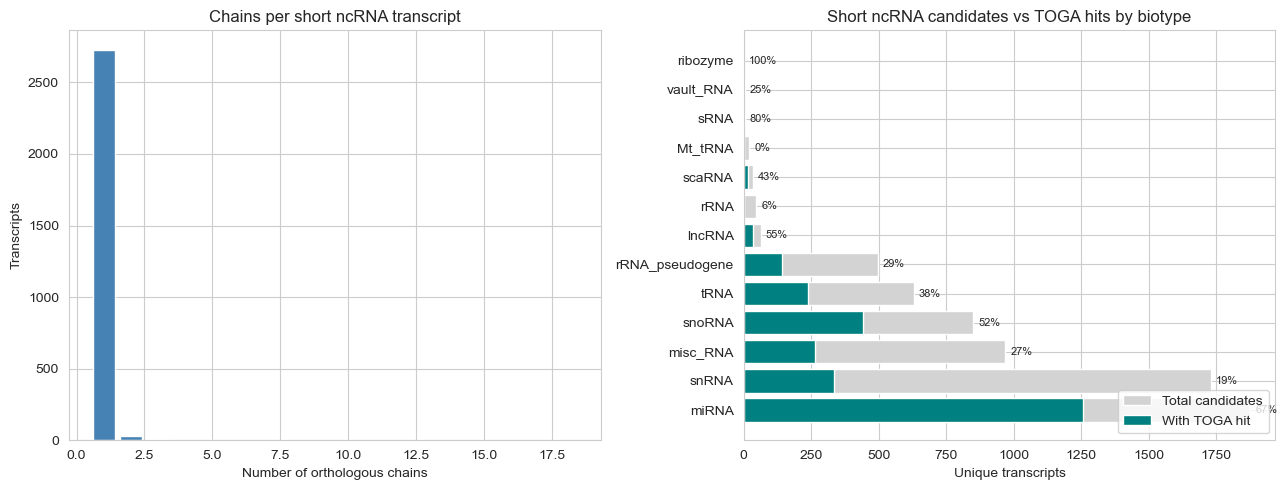

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: chain count distribution
chain_counts = chains_per_gene.value_counts().sort_index()
axes[0].bar(chain_counts.index, chain_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Number of orthologous chains")
axes[0].set_ylabel("Transcripts")
axes[0].set_title("Chains per short ncRNA transcript")

# Right: total candidates vs TOGA hits per biotype
total_by_bt = short_candidates["biotype"].value_counts()
hit_ids_by_bt = (
    toga_short.drop_duplicates("transcript_id")
    .merge(short_candidates[["name", "biotype"]], left_on="transcript_id", right_on="name")
    ["biotype_y"].value_counts()
)
all_biotypes = total_by_bt.index.tolist()
totals = [total_by_bt.get(bt, 0) for bt in all_biotypes]
hits = [hit_ids_by_bt.get(bt, 0) for bt in all_biotypes]

y = np.arange(len(all_biotypes))
axes[1].barh(y, totals, color="lightgrey", edgecolor="white", label="Total candidates")
axes[1].barh(y, hits, color="teal", edgecolor="white", label="With TOGA hit")
axes[1].set_yticks(y)
axes[1].set_yticklabels(all_biotypes)
axes[1].set_xlabel("Unique transcripts")
axes[1].set_title("Short ncRNA candidates vs TOGA hits by biotype")
axes[1].legend(loc="lower right")

for i, (t, h) in enumerate(zip(totals, hits)):
    if t > 0:
        pct = 100 * h / t
        axes[1].text(t + max(totals) * 0.01, i, f"{pct:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 3. Joblist → results: what made it through the short ncRNA pipeline?

In [8]:
joblist = pd.read_csv(JOBLIST, sep="\t")
print(f"Joblist entries: {len(joblist):,}")
print(f"  unique transcripts: {joblist['transcript_id'].nunique():,}")

# Note: joblist can differ from toga_short because write_short_ncrna_joblist
# also checks single-exon in the BED, which we already filtered above.
# Any discrepancy here is worth investigating.

Joblist entries: 2,817
  unique transcripts: 2,742


In [9]:
# Final results — BED9 format
results_bed = pd.read_csv(
    RESULTS_BED, sep="\t", header=None,
    names=["chrom", "start", "end", "name", "score", "strand",
           "thick_start", "thick_end", "rgb"],
)

results_bed["chain_id"] = results_bed["name"].str.rsplit(".", n=1).str[-1].astype(int)
results_bed["base_name"] = results_bed["name"].str.rsplit(".", n=1).str[0]

print(f"Final results: {len(results_bed):,} entries")
print(f"  unique genes: {results_bed['base_name'].nunique():,}")

Final results: 2,805 entries
  unique genes: 2,687


In [10]:
# Load details TSV for richer analysis (has MMD scores, biotypes)
details = pd.read_csv(DETAILS_TSV, sep="\t")
details["mmd_score"] = pd.to_numeric(details["mmd_score"], errors="coerce")

print(f"Details TSV: {len(details):,} rows")
print(f"\nBiotype breakdown in results:")
for bt, n in details["biotype"].value_counts().items():
    print(f"  {bt}: {n:,}")

Details TSV: 2,805 rows

Biotype breakdown in results:
  miRNA: 1,278
  snoRNA: 447
  snRNA: 350
  misc_RNA: 267
  tRNA: 255
  rRNA_pseudogene: 145
  lncRNA: 35
  scaRNA: 15
  sRNA: 7
  rRNA: 3
  ribozyme: 2
  vault_RNA: 1


## 4. Losses at each stage (funnel)

In [11]:
stages = [
    ("Union transcripts (short ncRNA candidates)", len(short_candidates)),
    ("With TOGA orthologous region", len(candidate_ids & toga_hit_ids)),
    ("Joblist entries (transcript × chain)", len(joblist)),
    ("Final results", len(results_bed)),
]

print(f"{'Stage':<50} {'Count':>7}  {'% of input':>10}")
print("-" * 72)
for label, count in stages:
    pct = 100 * count / stages[0][1] if stages[0][1] else 0
    print(f"{label:<50} {count:>7,}  {pct:>9.1f}%")

print()
# Losses between consecutive stages
print("Step-wise losses:")
for i in range(1, len(stages)):
    prev_label, prev_n = stages[i - 1]
    curr_label, curr_n = stages[i]
    lost = prev_n - curr_n
    if prev_n > 0:
        print(f"  {prev_label} → {curr_label}: "
              f"{'+' if lost < 0 else '-'}{abs(lost):,} "
              f"({100 * lost / prev_n:+.1f}%)")

Stage                                                Count  % of input
------------------------------------------------------------------------
Union transcripts (short ncRNA candidates)           6,733      100.0%
With TOGA orthologous region                         2,742       40.7%
Joblist entries (transcript × chain)                 2,817       41.8%
Final results                                        2,805       41.7%

Step-wise losses:
  Union transcripts (short ncRNA candidates) → With TOGA orthologous region: -3,991 (+59.3%)
  With TOGA orthologous region → Joblist entries (transcript × chain): +75 (-2.7%)
  Joblist entries (transcript × chain) → Final results: -12 (+0.4%)


## 5. MMD score distribution

/var/folders/z7/ft06s3jj3qggbhqby221m2200000kt/T/ipykernel_8312/3938706638.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, y="biotype", x="mmd_score", order=order,


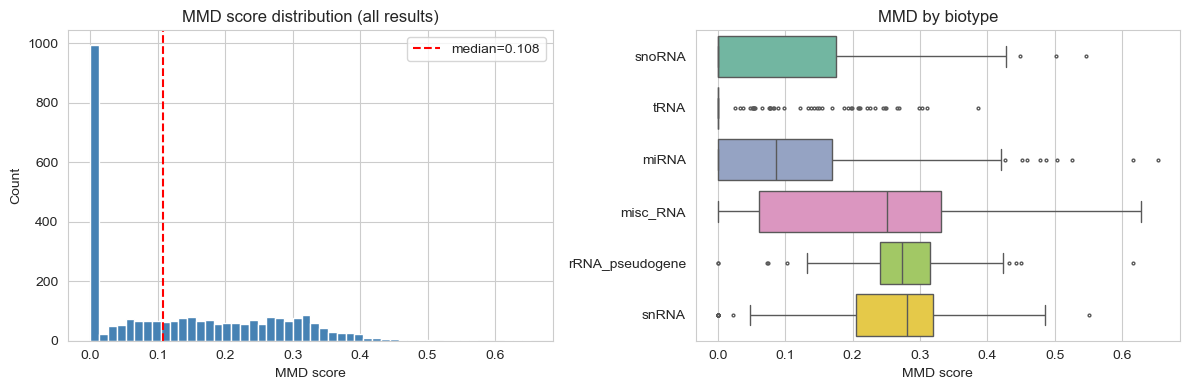

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall MMD distribution
axes[0].hist(details["mmd_score"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("MMD score")
axes[0].set_ylabel("Count")
axes[0].set_title("MMD score distribution (all results)")
axes[0].axvline(details["mmd_score"].median(), color="red", ls="--",
                label=f"median={details['mmd_score'].median():.3f}")
axes[0].legend()

# Per-biotype boxplot
top_biotypes = details["biotype"].value_counts().head(6).index.tolist()
subset = details[details["biotype"].isin(top_biotypes)]
order = subset.groupby("biotype")["mmd_score"].median().sort_values().index
sns.boxplot(data=subset, y="biotype", x="mmd_score", order=order,
            ax=axes[1], palette="Set2", fliersize=2)
axes[1].set_title("MMD by biotype")
axes[1].set_xlabel("MMD score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 6. Biotypes lost at TOGA stage

Which short ncRNA biotypes are disproportionately lost (no TOGA hit)?

In [13]:
short_with_bt = short_candidates[["name", "biotype"]].copy()
short_with_bt["has_toga_hit"] = short_with_bt["name"].isin(toga_hit_ids)

loss_by_bt = short_with_bt.groupby("biotype").agg(
    total=("name", "count"),
    with_hit=("has_toga_hit", "sum"),
).assign(
    lost=lambda df: df["total"] - df["with_hit"],
    pct_lost=lambda df: 100 * (df["total"] - df["with_hit"]) / df["total"],
).sort_values("total", ascending=False)

print(loss_by_bt.to_string())

                 total  with_hit  lost    pct_lost
biotype                                           
miRNA             1876      1256   620   33.049041
snRNA             1731       334  1397   80.704795
misc_RNA           969       266   703   72.549020
snoRNA             851       444   407   47.826087
tRNA               630       239   391   62.063492
rRNA_pseudogene    497       143   354   71.227364
lncRNA              64        35    29   45.312500
rRNA                47         3    44   93.617021
scaRNA              35        15    20   57.142857
Mt_tRNA             22         0    22  100.000000
sRNA                 5         4     1   20.000000
vault_RNA            4         1     3   75.000000
ribozyme             2         2     0    0.000000


## 7. Overlap with mm39 annotation (GENCODE + tRNA)

For each prediction, find the best exon-level overlap with GENCODE mouse transcripts
and tRNA annotations. Report hit rates overall and stratified by biotype and MMD score.

In [16]:
from pyrion.io.bed import read_narrow_bed_file, read_bed12_file
from pyrion.ops.interval_ops import intersect_intervals

predictions = read_narrow_bed_file(str(RESULTS_BED))
annotation = read_bed12_file(str(ANNO_BED))
trna_annotation = read_bed12_file(str(TRNA_BED))

print(f"Predictions:  {len(predictions):,}")
print(f"GENCODE mm39: {len(annotation):,} transcripts")
print(f"tRNAs:        {len(trna_annotation):,} entries")

Predictions:  2,805
GENCODE mm39: 278,326 transcripts
tRNAs:        1,137 entries


In [17]:
# Build per-prediction overlap table
# Match each prediction to details TSV for biotype + MMD
detail_map = {}
for _, row in details.iterrows():
    tid = row["transcript_id"]
    cid = row["chain_id"]
    key = f"{tid}.{cid}"
    detail_map[key] = {"biotype": row["biotype"], "mmd_score": row["mmd_score"]}

rows = []
for pred in predictions:
    pred_arr = np.array([[pred.start, pred.end]])
    pred_len = pred.end - pred.start

    # GENCODE exon overlap
    hits = annotation.get_transcripts_in_interval(pred)
    best_bp, best_tid = 0, None
    for t in hits:
        isect = intersect_intervals(pred_arr, t.blocks)
        if len(isect) > 0:
            bp = int(np.sum(isect[:, 1] - isect[:, 0]))
            if bp > best_bp:
                best_bp, best_tid = bp, t.id

    # tRNA overlap
    trna_hits = trna_annotation.get_transcripts_in_interval(pred)
    best_trna_bp, best_trna_id = 0, None
    for t in trna_hits:
        isect = intersect_intervals(pred_arr, t.blocks)
        if len(isect) > 0:
            bp = int(np.sum(isect[:, 1] - isect[:, 0]))
            if bp > best_trna_bp:
                best_trna_bp, best_trna_id = bp, t.id

    combined_bp = max(best_bp, best_trna_bp)
    pid = pred.id or f"{pred.chrom}:{pred.start}-{pred.end}"
    info = detail_map.get(pid, {})
    rows.append({
        "pred_id": pid,
        "chrom": pred.chrom,
        "start": pred.start,
        "end": pred.end,
        "length": pred_len,
        "biotype": info.get("biotype", "unknown"),
        "mmd_score": info.get("mmd_score", np.nan),
        "gencode_bp": best_bp,
        "gencode_pct": best_bp / pred_len * 100 if pred_len > 0 else 0,
        "trna_bp": best_trna_bp,
        "trna_pct": best_trna_bp / pred_len * 100 if pred_len > 0 else 0,
        "best_bp": combined_bp,
        "best_pct": combined_bp / pred_len * 100 if pred_len > 0 else 0,
        "best_match": best_tid if best_bp >= best_trna_bp else best_trna_id,
    })

ov = pd.DataFrame(rows)
ov["has_overlap"] = ov["best_bp"] > 0
ov["over50"] = ov["best_pct"] >= 50

print(f"Computed overlaps for {len(ov):,} predictions")

Computed overlaps for 2,805 predictions


In [18]:
# Overall summary
n = len(ov)
n_any = ov["has_overlap"].sum()
n_50 = ov["over50"].sum()
n_full = (ov["best_pct"] >= 99).sum()

print(f"=== Overlap Summary ===")
print(f"Total predictions:       {n:,}")
print(f"Any exon overlap:        {n_any:,}  ({100*n_any/n:.1f}%)")
print(f"≥50% overlap:            {n_50:,}  ({100*n_50/n:.1f}%)")
print(f"≥99% overlap (full):     {n_full:,}  ({100*n_full/n:.1f}%)")
print(f"No overlap:              {n - n_any:,}  ({100*(n - n_any)/n:.1f}%)")

hits = ov[ov["has_overlap"]]
if len(hits) > 0:
    print(f"\nAmong {n_any:,} with overlap:")
    print(f"  median overlap: {hits['best_pct'].median():.1f}%")
    print(f"  mean overlap:   {hits['best_pct'].mean():.1f}%")

=== Overlap Summary ===
Total predictions:       2,805
Any exon overlap:        1,489  (53.1%)
≥50% overlap:            1,339  (47.7%)
≥99% overlap (full):     996  (35.5%)
No overlap:              1,316  (46.9%)

Among 1,489 with overlap:
  median overlap: 100.0%
  mean overlap:   88.8%


=== Overlap by biotype ===
           total  any_overlap  over_50  median_pct  median_mmd  hit_rate  over50_rate
biotype                                                                              
unknown     1935         1072      928   17.857143         NaN      55.4         48.0
tRNA         255          226      226  100.000000    0.000000      88.6         88.6
snRNA        218           23       20    0.000000    0.284272      10.6          9.2
misc_RNA     214          105      102    0.000000    0.202325      49.1         47.7
snoRNA       127           38       38    0.000000    0.216791      29.9         29.9
lncRNA        33           18       18   72.847682    0.090976      54.5         54.5
sRNA           7            2        2    0.000000    0.379341      28.6         28.6
miRNA          6            2        2    0.000000    0.109375      33.3         33.3
scaRNA         4            1        1    0.000000    0.242244      25.0         25.0
rRNA           3           

/var/folders/z7/ft06s3jj3qggbhqby221m2200000kt/T/ipykernel_8312/2536584891.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, y="biotype", x="best_pct", order=order,


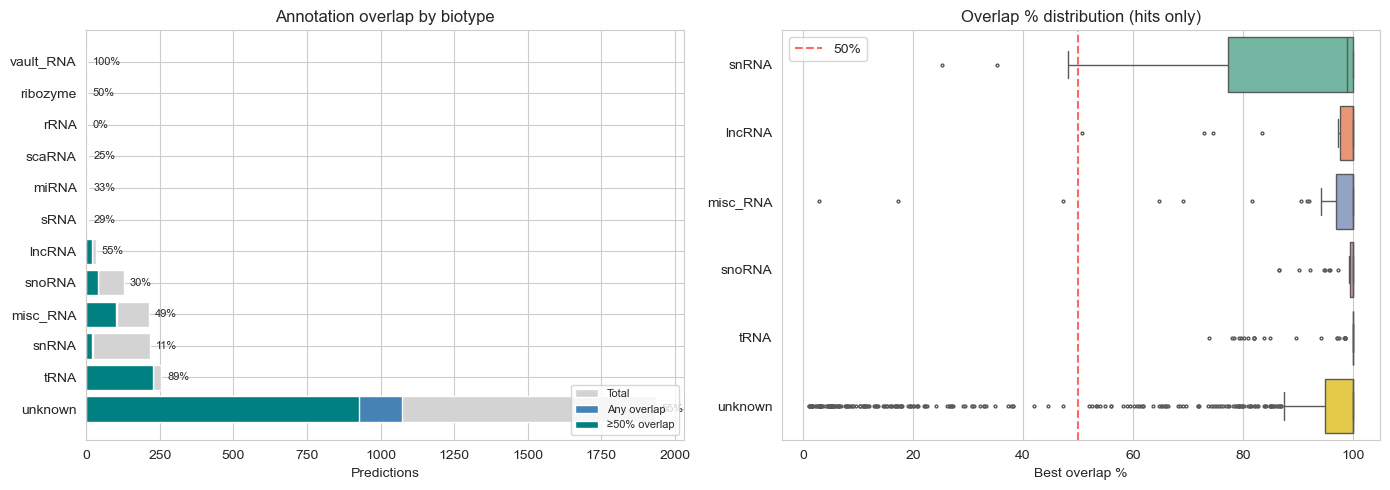

In [19]:
# Stratify by biotype
bt_stats = ov.groupby("biotype").agg(
    total=("pred_id", "count"),
    any_overlap=("has_overlap", "sum"),
    over_50=("over50", "sum"),
    median_pct=("best_pct", "median"),
    median_mmd=("mmd_score", "median"),
).sort_values("total", ascending=False)
bt_stats["hit_rate"] = (100 * bt_stats["any_overlap"] / bt_stats["total"]).round(1)
bt_stats["over50_rate"] = (100 * bt_stats["over_50"] / bt_stats["total"]).round(1)

print("=== Overlap by biotype ===")
print(bt_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total vs overlap vs ≥50% per biotype
biotypes = bt_stats.index.tolist()
y = np.arange(len(biotypes))
axes[0].barh(y, bt_stats["total"], color="lightgrey", edgecolor="white", label="Total")
axes[0].barh(y, bt_stats["any_overlap"], color="steelblue", edgecolor="white", label="Any overlap")
axes[0].barh(y, bt_stats["over_50"], color="teal", edgecolor="white", label="≥50% overlap")
axes[0].set_yticks(y)
axes[0].set_yticklabels(biotypes)
axes[0].set_xlabel("Predictions")
axes[0].set_title("Annotation overlap by biotype")
axes[0].legend(loc="lower right", fontsize=8)
for i, (tot, hit) in enumerate(zip(bt_stats["total"], bt_stats["any_overlap"])):
    if tot > 0:
        axes[0].text(tot + max(bt_stats["total"]) * 0.01, i,
                     f"{100*hit/tot:.0f}%", va="center", fontsize=8)

# Right: overlap % distribution, coloured by biotype
top_bts = bt_stats.head(6).index.tolist()
sub = ov[ov["biotype"].isin(top_bts) & ov["has_overlap"]]
if len(sub) > 0:
    order = sub.groupby("biotype")["best_pct"].median().sort_values().index
    sns.boxplot(data=sub, y="biotype", x="best_pct", order=order,
                ax=axes[1], palette="Set2", fliersize=2)
    axes[1].axvline(50, color="red", ls="--", alpha=0.6, label="50%")
    axes[1].set_xlabel("Best overlap %")
    axes[1].set_ylabel("")
    axes[1].set_title("Overlap % distribution (hits only)")
    axes[1].legend()

plt.tight_layout()
plt.show()

=== Overlap by MMD score ===
         total  any_overlap  over_50  median_pct  hit_rate  over50_rate
mmd_bin                                                                
<0.1       382          345      345       100.0      90.3         90.3
0.1–0.2    110           32       31         0.0      29.1         28.2
0.2–0.3    177           14       14         0.0       7.9          7.9
0.3–0.5    197           26       21         0.0      13.2         10.7
≥0.5         4            0        0         0.0       0.0          0.0


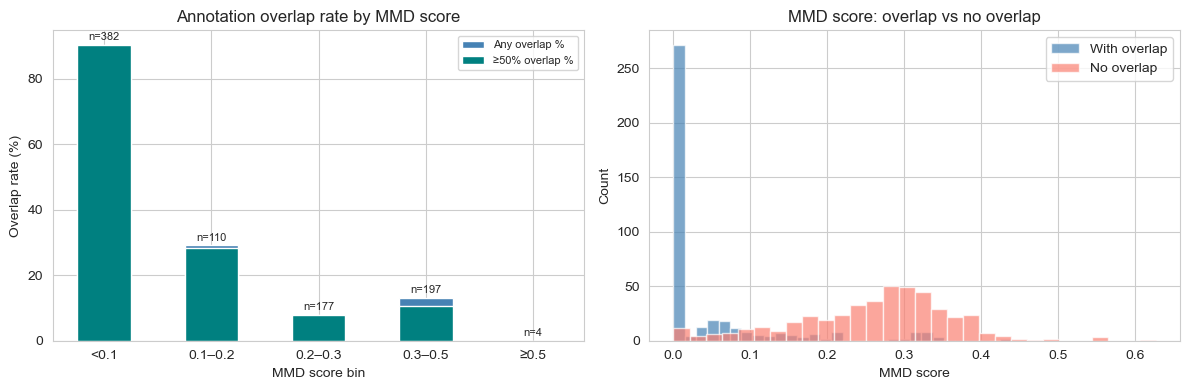

In [20]:
# Stratify by MMD score
mmd_bins = [0, 0.1, 0.2, 0.3, 0.5, 1.01]
mmd_labels = ["<0.1", "0.1–0.2", "0.2–0.3", "0.3–0.5", "≥0.5"]
ov["mmd_bin"] = pd.cut(ov["mmd_score"], bins=mmd_bins, labels=mmd_labels, right=False)

mmd_stats = ov.groupby("mmd_bin", observed=False).agg(
    total=("pred_id", "count"),
    any_overlap=("has_overlap", "sum"),
    over_50=("over50", "sum"),
    median_pct=("best_pct", "median"),
)
mmd_stats["hit_rate"] = (100 * mmd_stats["any_overlap"] / mmd_stats["total"]).round(1)
mmd_stats["over50_rate"] = (100 * mmd_stats["over_50"] / mmd_stats["total"]).round(1)

print("=== Overlap by MMD score ===")
print(mmd_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overlap rate by MMD bin
x = np.arange(len(mmd_labels))
axes[0].bar(x, mmd_stats["hit_rate"], color="steelblue", edgecolor="white", width=0.5,
            label="Any overlap %")
axes[0].bar(x, mmd_stats["over50_rate"], color="teal", edgecolor="white", width=0.5,
            label="≥50% overlap %")
axes[0].set_xticks(x)
axes[0].set_xticklabels(mmd_labels)
axes[0].set_xlabel("MMD score bin")
axes[0].set_ylabel("Overlap rate (%)")
axes[0].set_title("Annotation overlap rate by MMD score")
axes[0].legend(fontsize=8)
for i, tot in enumerate(mmd_stats["total"]):
    axes[0].text(i, max(mmd_stats["hit_rate"].iloc[i], mmd_stats["over50_rate"].iloc[i]) + 1.5,
                 f"n={tot}", ha="center", fontsize=8)

# Right: MMD score distribution split by overlap status
axes[1].hist(ov[ov["has_overlap"]]["mmd_score"].dropna(), bins=30, alpha=0.7,
             color="steelblue", edgecolor="white", label="With overlap")
axes[1].hist(ov[~ov["has_overlap"]]["mmd_score"].dropna(), bins=30, alpha=0.7,
             color="salmon", edgecolor="white", label="No overlap")
axes[1].set_xlabel("MMD score")
axes[1].set_ylabel("Count")
axes[1].set_title("MMD score: overlap vs no overlap")
axes[1].legend()

plt.tight_layout()
plt.show()